In [14]:
import pandas as pd
import json
import lightgbm as lgb
from numerai_tools.scoring import numerai_corr, correlation_contribution
import optuna
from optuna.storages import JournalStorage, JournalFileStorage
import cloudpickle

from numerapi import NumerAPI

napi = NumerAPI()
DATA_VERSION = "v5.2"
all_datasets = napi.list_datasets()
dataset_versions = list(set(d.split('/')[0] for d in all_datasets))
current_version_files = [f for f in all_datasets if f.startswith(DATA_VERSION)]

In [5]:
napi.download_dataset(f"{DATA_VERSION}/features.json")
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))

feature_sets = feature_metadata["feature_sets"]

feature_set = feature_sets["small"]
napi.download_dataset(f"{DATA_VERSION}/train.parquet")
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
napi.download_dataset(f"v4.3/meta_model.parquet", round_num=842)

2026-02-25 19:42:08,077 INFO numerapi.utils: target file already exists
2026-02-25 19:42:08,079 INFO numerapi.utils: download complete
2026-02-25 19:42:09,156 INFO numerapi.utils: target file already exists
2026-02-25 19:42:09,157 INFO numerapi.utils: download complete
2026-02-25 19:42:10,289 INFO numerapi.utils: target file already exists
2026-02-25 19:42:10,290 INFO numerapi.utils: download complete
2026-02-25 19:42:11,325 INFO numerapi.utils: target file already exists
2026-02-25 19:42:11,326 INFO numerapi.utils: download complete


'v4.3/meta_model.parquet'

In [6]:
# Load only the "medium" feature set to
# Use the "all" feature set to use all features
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# # Downsample to every 4th era to reduce memory usage and speedup model training (suggested for Colab free tier)
# # Comment out the line below to use all the data
# train = train[train["era"].isin(train["era"].unique()[::4])]

# Load the validation data and filter for data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# # Downsample to every 4th era to reduce memory usage and speedup evaluation (suggested for Colab free tier)
# # Comment out the line below to use all the data (slower and higher memory usage, but more accurate evaluation)
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Eras are 1 week apart, but targets look 20 days (o 4 weeks/eras) into the future,
# so we need to "embargo" the first 4 eras following our last train era to avoid "data leakage"
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Parameter Optimization

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "num_leaves": trial.suggest_int("num_leaves", 16, 2**10),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 0.5),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 100, 10000),
        "device": "cpu",          # <-- was "gpu", no OpenCL available
        "random_state": 42,
        "verbosity": -1
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(train[feature_set], train["target"])

    validation["prediction"] = model.predict(validation[feature_set])

    per_era_corr = validation.groupby("era").apply(
        lambda x: numerai_corr(x[["prediction"]].dropna(), x["target"].dropna())
    )

    corr_mean = per_era_corr.mean()
    corr_std = per_era_corr.std(ddof=0) + 1e-6
    corr_sharpe = (corr_mean / corr_std).item()

    return corr_sharpe

# Shared SQLite storage so parallel workers don't collide
storage = JournalStorage(JournalFileStorage("optuna_journal.log"))

study = optuna.create_study(
    study_name="lgbm_numerai",
    storage=storage,
    direction="maximize",
    load_if_exists=True,   # safe to re-run / resume
)

# n_jobs=-1 uses all available CPUs
study.optimize(objective, n_trials=100, n_jobs=-1)

print(f"Best Sharpe Ratio: {study.best_value:.4f}")
print(f"Best Parameters:   {study.best_params}")

/tmp/ipykernel_910030/2067770850.py:33: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  storage = JournalStorage(JournalFileStorage("optuna_journal.log"))
[I 2026-02-25 14:10:01,030] A new study created in Journal with name: lgbm_numerai
[I 2026-02-25 14:25:59,685] Trial 54 finished with value: 0.7437455381985699 and parameters: {'n_estimators': 193, 'learning_rate': 0.003122540406239194, 'max_depth': 3, 'num_leaves': 149, 'colsample_bytree': 0.17325703541163667, 'min_data_in_leaf': 9469}. Best is trial 54 with value: 0.7437455381985699.
[I 2026-02-25 14:36:56,701] Trial 5 finished with value: 0.7134308738837079 and parameters: {'n_estimators': 419, 'learning_rate': 0.0024682592187070026, 'max_depth': 2, 'num_leaves': 602, 'colsample_bytree': 0.08261771865977874, 'min_data_in_leaf': 1379}. Best is trial 54

Best Sharpe Ratio: 1.0108
Best Parameters:   {'n_estimators': 662, 'learning_rate': 0.01765468311647915, 'max_depth': 7, 'num_leaves': 913, 'colsample_bytree': 0.4849699983028804, 'min_data_in_leaf': 3799}


In [9]:
best_params = {
    "n_estimators": 662,
    "learning_rate": 0.01765468311647915,
    "max_depth": 7,
    "num_leaves": 913,
    "colsample_bytree": 0.4849699983028804,
    "min_data_in_leaf": 3799,
    "device": "cpu",
    "random_state": 42,
    "verbosity": -1
}

model = lgb.LGBMRegressor(**best_params)
model.fit(train[feature_set], train["target"])

# Generate predictions against the out-of-sample validation features
validation["prediction"] = model.predict(validation[feature_set])
validation["meta_model"] = pd.read_parquet(f"v4.3/meta_model.parquet")["numerai_meta_model"]
validation[["era", "prediction", "target"]]

,era,prediction,target
id,,,
n0005339ce5e6cad,0578,0.498185,0.50
n001e265c6584874,0578,0.502179,0.25
n0029194621a1a63,0578,0.503401,0.00
n0046736de1c970b,0578,0.508442,0.75
n00505cd5d2350de,0578,0.497426,0.50
...,...,...,...
nffdcbd6f6bea5a6,1203,0.503103,0.50
nffe39ce31ef5176,1203,0.500564,0.50
nffe72d1e5ac3e40,1203,0.498918,0.50


# Performance Evaluation

,CORR,MMC
mean,0.014904,0.007902
std,0.014744,0.012973
sharpe,1.010866,0.609116
max_drawdown,0.127709,0.089500


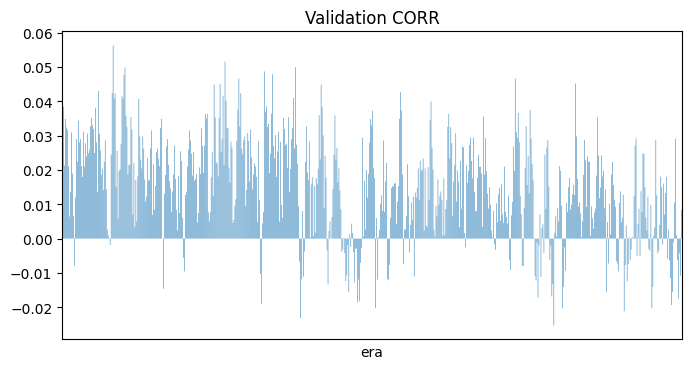

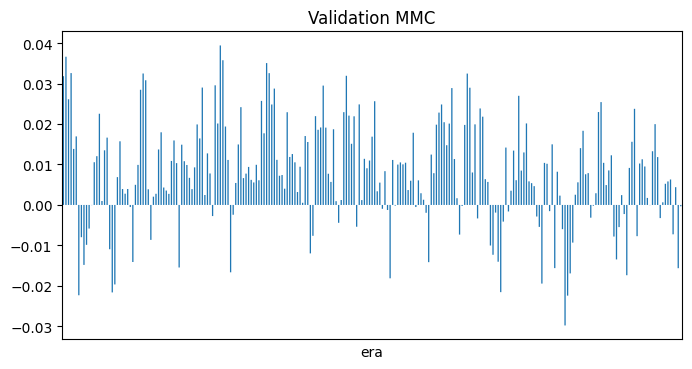

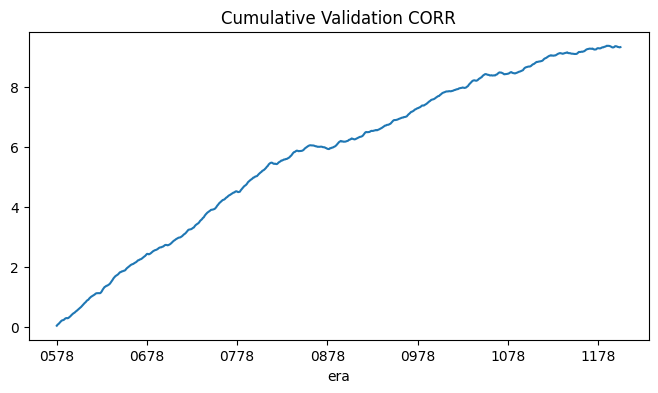

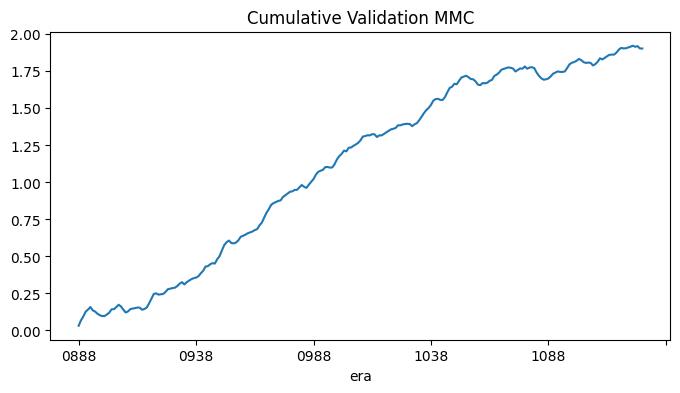

In [12]:
# Compute the per-era corr between our predictions and the target values
per_era_corr = validation.groupby("era").apply(
    lambda x: numerai_corr(x[["prediction"]].dropna(), x["target"].dropna())
)

# Compute the per-era mmc between our predictions, the meta model, and the target values
per_era_mmc = validation.dropna().groupby("era").apply(
    lambda x: correlation_contribution(x[["prediction"]], x["meta_model"], x["target"])
)

# Plot the per-era correlation
per_era_corr.plot(
  title="Validation CORR",
  kind="bar",
  figsize=(8, 4),
  xticks=[],
  legend=False,
  snap=False
)
per_era_mmc.plot(
  title="Validation MMC",
  kind="bar",
  figsize=(8, 4),
  xticks=[],
  legend=False,
  snap=False
)

# Plot the cumulative per-era correlation
per_era_corr.cumsum().plot(
  title="Cumulative Validation CORR",
  kind="line",
  figsize=(8, 4),
  legend=False
)
per_era_mmc.cumsum().plot(
  title="Cumulative Validation MMC",
  kind="line",
  figsize=(8, 4),
  legend=False
)

# Compute performance metrics
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
corr_max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

mmc_mean = per_era_mmc.mean()
mmc_std = per_era_mmc.std(ddof=0)
mmc_sharpe = mmc_mean / mmc_std
mmc_max_drawdown = (per_era_mmc.cumsum().expanding(min_periods=1).max() - per_era_mmc.cumsum()).max()

pd.DataFrame({
    "mean": [corr_mean.item(), mmc_mean.item()],
    "std": [corr_std.item(), mmc_std.item()],
    "sharpe": [corr_sharpe.item(), mmc_sharpe.item()],
    "max_drawdown": [corr_max_drawdown.item(), mmc_max_drawdown.item()]
}, index=["CORR", "MMC"]).T

# Submission

In [13]:
# Download latest live features
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Load live features
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Generate live predictions
live_predictions = model.predict(live_features[feature_set])

# Format submission
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2026-02-25 19:48:19,324 INFO numerapi.utils: starting download
v5.2/live.parquet: 9.97MB [00:02, 4.05MB/s]                            


,prediction
id,
n00019f08a66b008,0.509332
n00059faff1cb6cc,0.488080
n00185c0702aacba,0.494292
n001e7666d0d12df,0.504585
n002a5498b33530f,0.506088
...,...
nffee73bd4dcaae5,0.499495
nfff23cde0965517,0.503458
nfff6bffbbf21203,0.485652


In [15]:
# Define your prediction pipeline as a function
def predict(live_features: pd.DataFrame) -> pd.DataFrame:
    live_predictions = model.predict(live_features[feature_set])
    submission = pd.Series(live_predictions, index=live_features.index)
    return submission.to_frame("prediction")

# Use the cloudpickle library to serialize your function
p = cloudpickle.dumps(predict)
with open("hello_numerai.pkl", "wb") as f:
    f.write(p)